In [18]:
from jax_unirep import get_reps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import *
from sklearn import manifold
from sklearn.decomposition import PCA
import warnings
import string
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [20]:
def make_heatmap(data, name, incubation_time, quantity='conversion', save=False):
    rows = list(string.ascii_uppercase[:8][::-1])
    cols = list(range(1,13))
    #quantity = 'conversion'

    data = np.array(data[quantity]).reshape((8,12))

    fig, ax = plt.subplots(dpi=400)
    im = ax.imshow(data, extent=[0, 12, 0, 8] )
    #ax.pcolormesh(data, edgecolors='k', linewidth=2)
    ax.grid(which = 'minor',color='w', linestyle='-', linewidth=2)
    plt.xticks(np.arange(len(cols))+0.5, labels=cols)
    ax.set_yticks(np.arange(len(rows))+0.5, labels=rows)
    plt.xlim(0,12)
    title = name+' '+quantity+', '+incubation_time
    plt.title(title)

    #ax.grid(color='k', linestyle='-', linewidth=2)
    for j, i in product(np.arange(len(cols)),np.arange(len(rows))):
        l = ax.axvline(j, color='k', linewidth=2)
        l = ax.axhline(i, color='k', linewidth=2)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)
    cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")
    if save == True:
        plt.savefig(title+'.png')

In [10]:
pdf_df = pd.read_csv('result_data/PatDf-ArtGox-2d.csv')
patg_df = pd.read_csv('result_data/PatG-2d.csv')

In [11]:
pdf_df.rename(columns={'conversion':'het_conversion', 'tot_ions':'het_tot_ions'},inplace=True)
#pdf_df.head()

In [46]:
patg_df.rename(columns={'conversion':'cyc_conversion',
                        'tot_ions':'cyc_tot_ions', 
                        'L(tot)_x':'L(tot)_cyc',
                        'L(tot)_y':'L(tot)_het'},inplace=True)
#patg_df.head()

In [47]:
assay_data = patg_df.merge(pdf_df, on='peptide')
assay_data.drop(assay_data.columns[0], axis=1, inplace=True)
assay_data.rename(columns={'L(tot)_x':'L(tot)_cyc',
                        'L(tot)_y':'L(tot)_het'},inplace=True)
assay_data.loc[:,'oxidation'] = assay_data['LHO(tot)']/(assay_data[['LHR(tot)', 'LHO(tot)']].sum(axis=1))*100
assay_data.loc[assay_data['het_conversion'] == 0,'oxidation'] = 0
assay_data.head()

,peptide,L(m+1)_x,L(m+2)_x,L(m+3)_x,C(m+1),C(m+2),C(m+3),L(tot)_cyc,C(tot),cyc_conversion,...,L(tot)_het,LHR(tot),LHO(tot),LH_MULTI,het_conversion,het_tot_ions,LH_MULTI_conversion,well_y,unfiltered_conversion_y,oxidation
0,DVQAFTAPAYDG,7531986.0,19669095.0,59709.0,88516.0,69056.0,2540.0,27260790.0,160112.0,0.583905,...,375053.0,312617.0,1154121.0,559618.0,0.000000,2401409.0,23.303735,A1,79.636506,0.000000
1,GYLKWTAPAYDG,1461095.0,24657462.0,447433.0,529422.0,535984.0,4738.0,26565990.0,1070144.0,3.872264,...,16385549.0,687467.0,729064.0,274552.0,7.957110,18076632.0,1.518823,A2,7.957110,51.468270
2,GAEWRTAPAYDG,1017100.0,22716457.0,547222.0,61689.0,236353.0,2224.0,24280779.0,300266.0,1.221535,...,17133977.0,694963.0,130246.0,140805.0,4.594913,18099991.0,0.777929,A3,4.594913,15.783395
3,IDFVKTAPAYDG,2002792.0,39992708.0,954651.0,128221.0,145504.0,2890.0,42950151.0,276615.0,0.639916,...,460823.0,305634.0,622162.0,508409.0,0.000000,1897028.0,26.800290,A4,66.814295,0.000000
4,WLYKDTAPAYDG,1185543.0,33413060.0,812739.0,588560.0,695039.0,7799.0,35411342.0,1291398.0,3.518533,...,22006328.0,1358801.0,100412.0,107559.0,6.218536,23573100.0,0.456279,A5,6.218536,6.881244


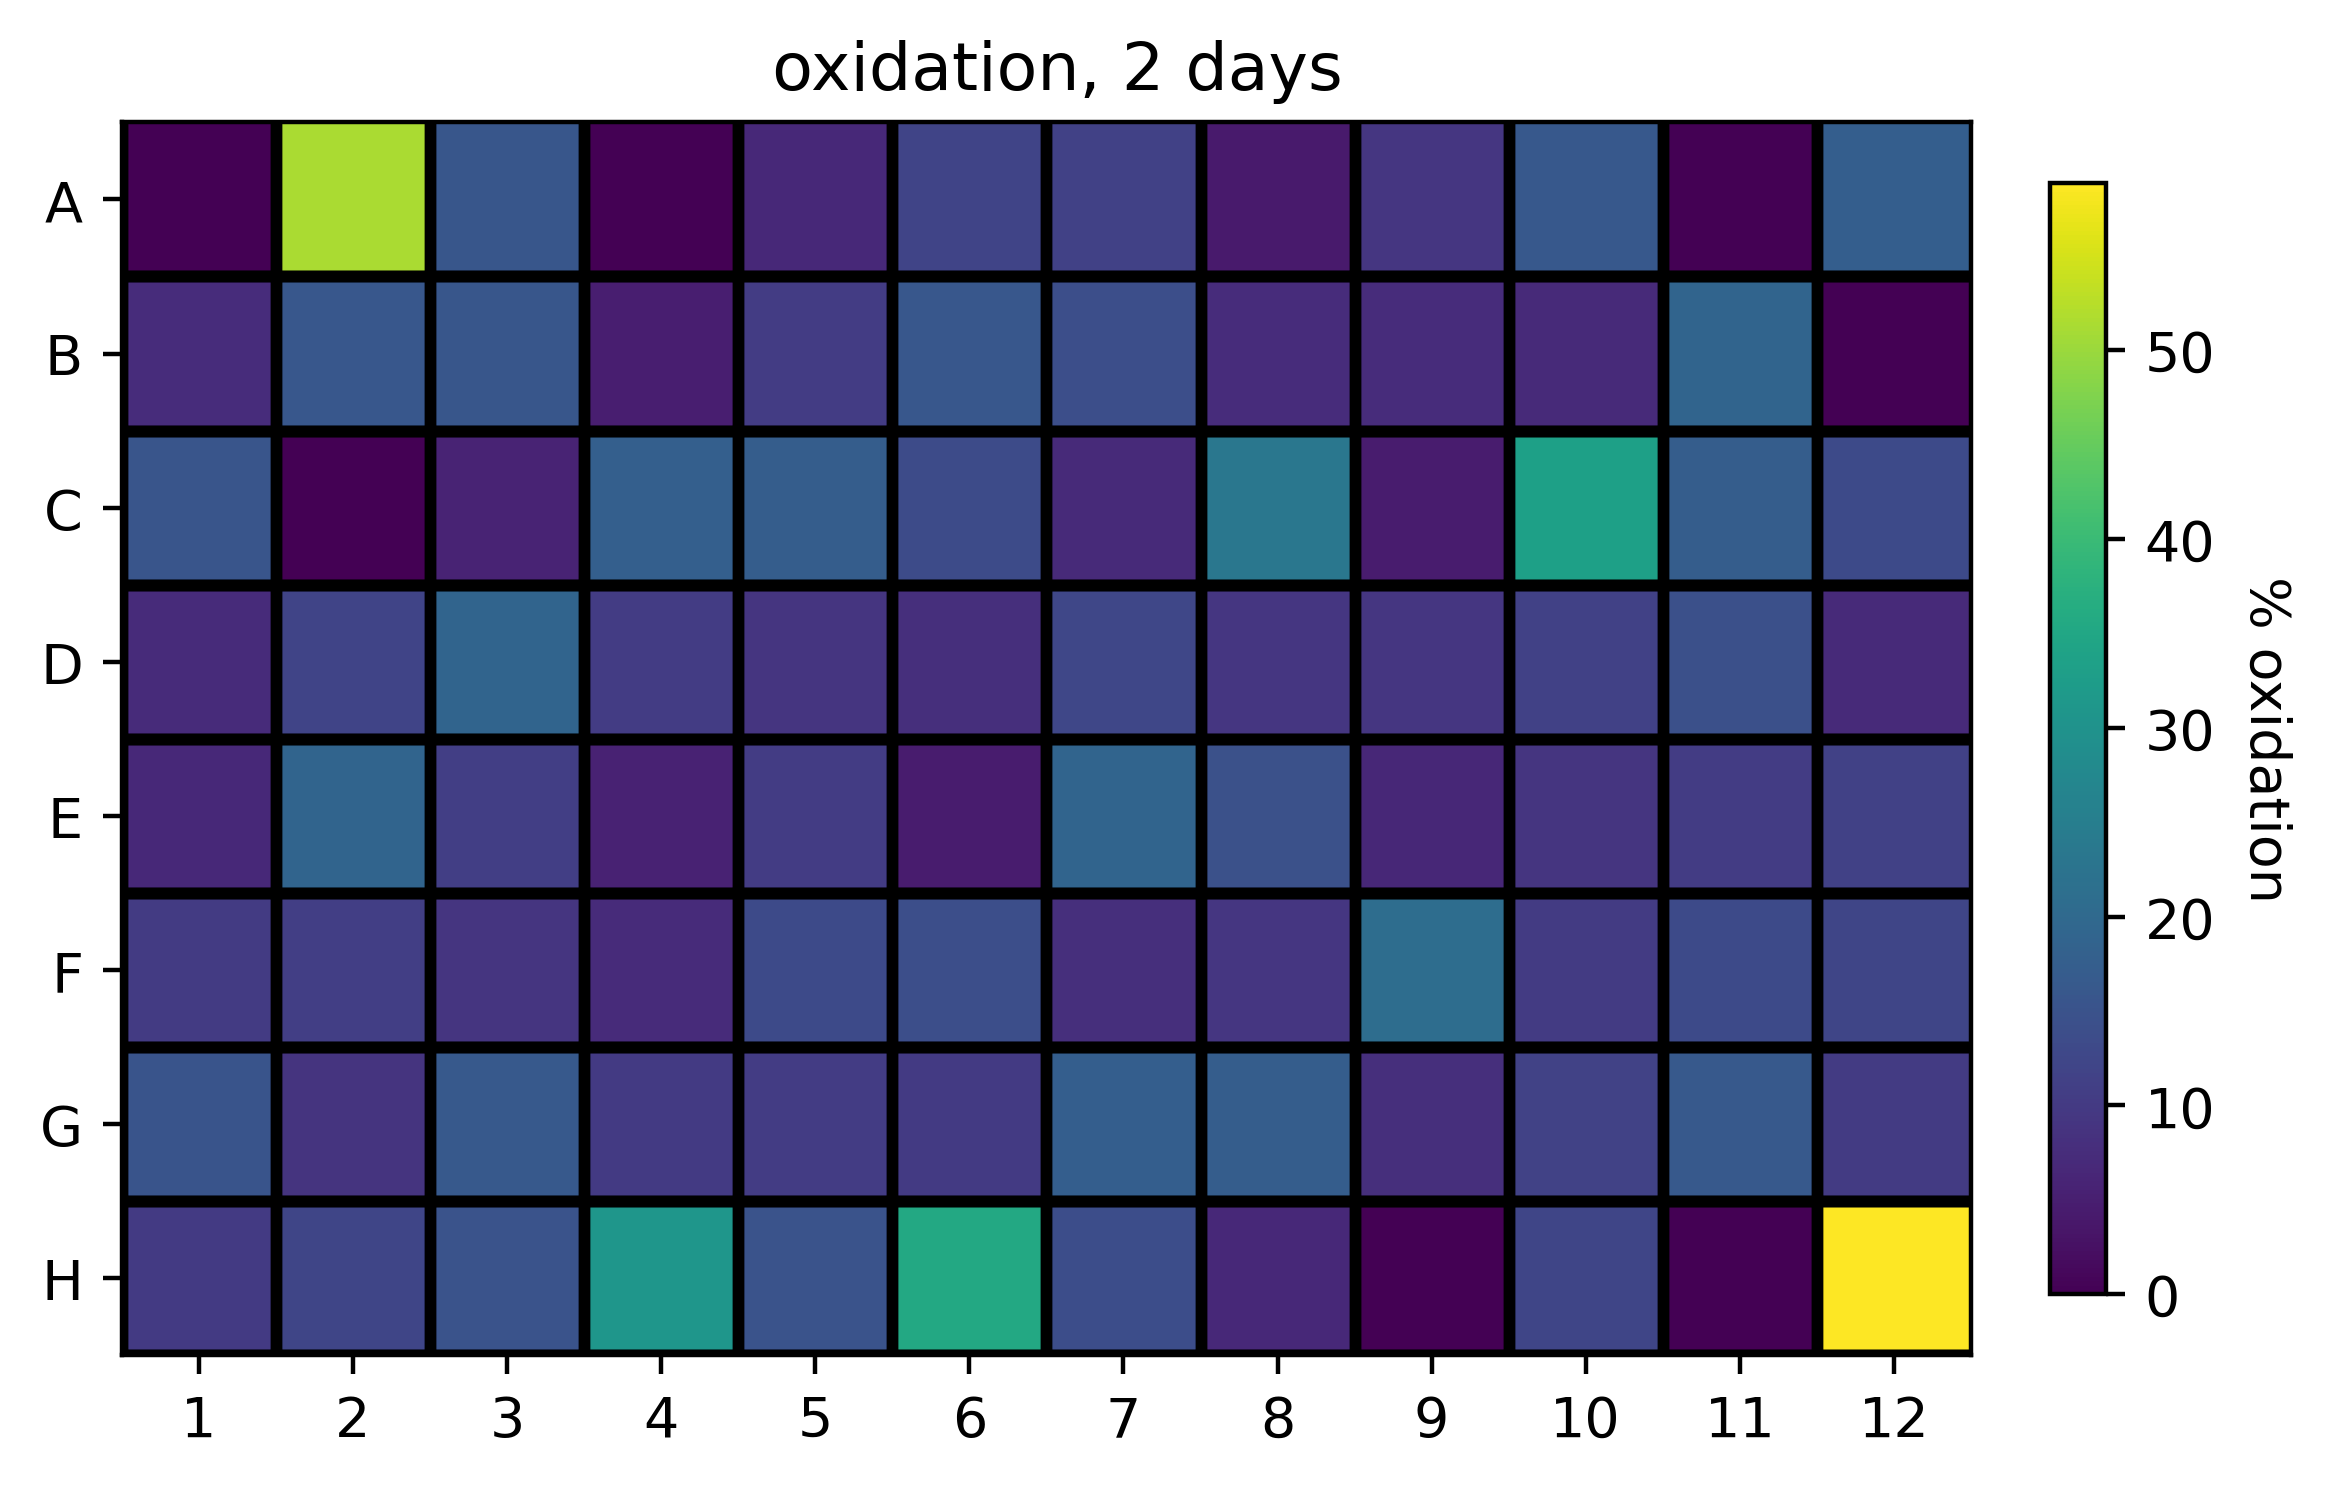

In [ ]:
make_heatmap(assay_data, '', '2 days', 'oxidation', save=False)
make_heatmap(assay_data, '', '2 days', 'het_conversion', save=False)
make_heatmap(assay_data, '', '2 days', 'cyc_conversion', save=False)

# unirep encoding and PCA

In [49]:
pep_seqs = [i[:5] for i in assay_data['peptide']]
h_avg, h_final, c_final = get_reps(pep_seqs)
#h_avg=h_avg.T-h_avg.mean(axis=1)
#h_avg=h_avg.T

In [50]:
tsne = manifold.TSNE(n_components=2, random_state=42)
peptide_rep = tsne.fit_transform(h_avg)
pca = PCA(n_components=2, random_state=42)
peptide_pca = pca.fit_transform(h_avg)

assay_data['tsne1'], assay_data['tsne2'] = peptide_rep[:,0], peptide_rep[:,1]
assay_data['pca1'], assay_data['pca2'] = peptide_pca[:,0], peptide_pca[:,1]

In [51]:
path='/home/debonaa1/'
data = np.load(path+'/peptide_design/encoding/unirep_5mer_lib.npy')
orig_peptides = np.load(path+'/peptide_design/analysis/original_peptides.npy')
peptides = np.load(path+'/peptide_design/220510_5mer_library.npy')
orig_lib = np.load(path+'/peptide_design/analysis/unirep_orig_lib.npy')
pagg_lib = np.load(path+'/peptide_design/analysis/unirep_pagg_lib.npy')
pagg_pepseqs = np.load(path+'/peptide_design/analysis/pagg_lib.npy')
peptides = np.array([i[:5] for i in peptides]) # cut off constant region

n = round(data.shape[1])
df = pd.DataFrame(data[:, :n], index=peptides, columns = ['f'+str(i+1) for i in range(n)])

pagg_df = pd.DataFrame(pagg_lib, index=pagg_pepseqs, columns = ['f'+str(i+1) for i in range(n)])

df = df.loc[:, (df != 0).any(axis=0)]
df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f1891,f1892,f1893,f1894,f1895,f1896,f1897,f1898,f1899,f1900
GADEF,0.088081,0.009338,-0.065617,0.095007,-0.019542,0.123355,-0.478922,0.081878,-0.103119,0.340690,...,0.081366,0.206757,-0.042708,0.092970,0.096515,0.086592,0.128984,0.075844,0.100289,0.147611
GADEY,0.087717,0.001923,-0.064906,0.094970,-0.018008,0.120416,-0.486670,0.082191,-0.103004,0.364526,...,0.081988,0.213068,-0.034552,0.093551,0.097330,0.083450,0.110797,0.076784,0.100077,0.153797
GADEW,0.087417,0.010377,-0.064905,0.095069,-0.025019,0.118051,-0.539491,0.082061,-0.103094,0.357155,...,0.081070,0.217500,-0.058845,0.093839,0.097736,0.083797,0.133911,0.072035,0.104962,0.160443
GAEDF,0.088011,0.014842,-0.066400,0.095073,-0.023149,0.108661,-0.511065,0.082422,-0.103102,0.394067,...,0.080354,0.173559,-0.023201,0.093363,0.094061,0.083529,0.136344,0.069250,0.100708,0.149032
GAEDY,0.087580,0.007398,-0.065931,0.095051,-0.023436,0.106679,-0.521790,0.082775,-0.102975,0.426781,...,0.080429,0.187575,-0.024757,0.093796,0.094250,0.080417,0.116422,0.066809,0.098368,0.153544


In [52]:
all_pep = pd.concat([df, orig_df, pagg_df])


df = pd.DataFrame(df, index=peptides, columns = ['f'+str(i+1) for i in range(n)])



In [55]:
pca2 = PCA()
pca2.fit(df)
X_transform = pca2.transform(df)
print(X_transform.shape)
print(orig_lib.shape)
print(pagg_lib.shape)

(211320, 1900)
(80, 1900)
(120, 1900)


In [56]:
h_avg_encoding = pca2.transform(h_avg)
assay_data['pca1'], assay_data['pca2'] = h_avg_encoding[:,0], h_avg_encoding[:,1]

/home/debonaa1/.conda/envs/jax/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


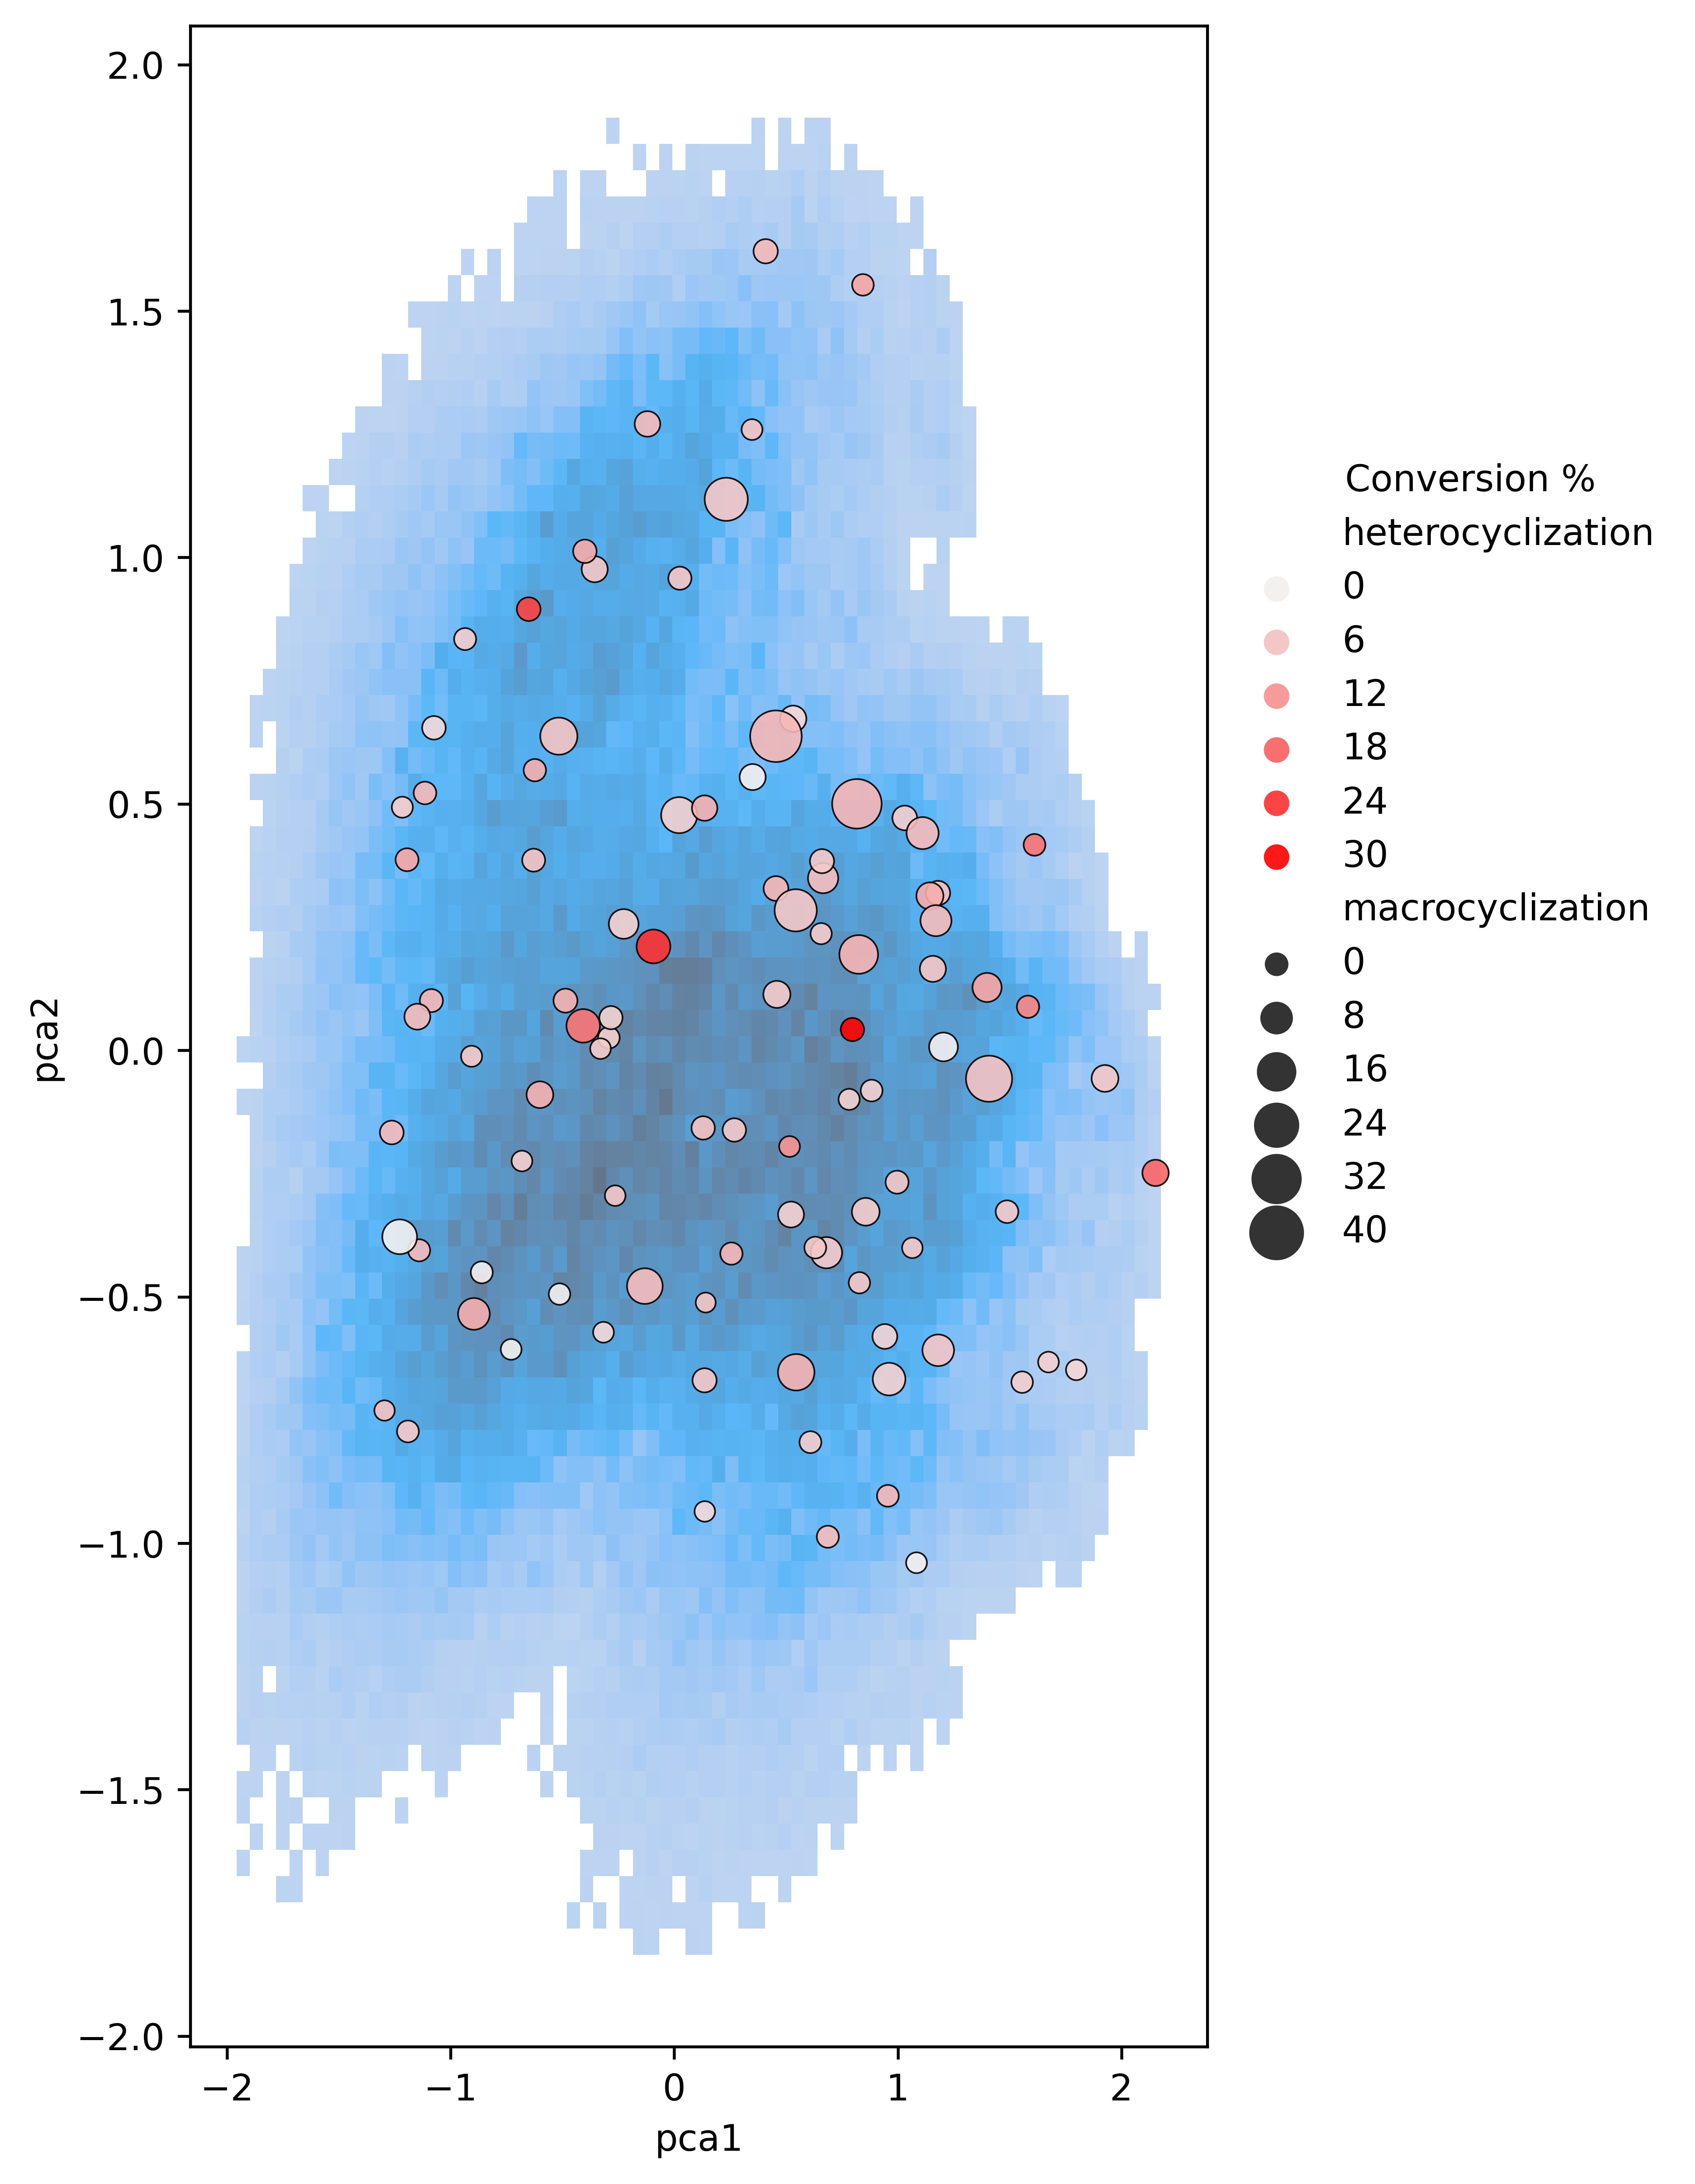

In [59]:
fig, axs = plt.subplots(1, 1, figsize=(5, 10), dpi=600)

cmap = sns.light_palette("red",as_cmap=True)
assay_data['heterocyclization'] = assay_data['het_conversion'] 
assay_data['macrocyclization'] = assay_data['cyc_conversion']

assay_data['pca1'] = assay_data['pca1']
assay_data['pca2'] = assay_data['pca2']
m = 'macrocyclization'
h = 'heterocyclization'
sns.histplot(x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8)
sns.scatterplot(x='pca1',y='pca2', data=assay_data, 
      size=m, sizes=(30,200),
      hue=h, palette=cmap, 
      edgecolor='k', alpha=0.9)

#plt.setp(ax.spines.values(), linewidth=2)
#axs.tick_params(width=1)
plt.legend(bbox_to_anchor=(1.0, 0.8), title='    Conversion %',frameon=False)
plt.savefig('library_screen.pdf', bbox_inches='tight', format='pdf')

In [61]:
data = assay_data[['heterocyclization', 'macrocyclization', 'peptide', 'oxidation']]

In [65]:
cat_dict={'neut':['G', 'A', 'V', 'I', 'L', 'N', 'Q', 'H'],
            'neg': ['D', 'E'],
            'aromat': ['F', 'Y', 'W'],
            'pos': ['K', 'R'],
            'het': ['S', 'T']
            }


inv_cat_dict = {}
for key in cat_dict.keys():
    for item in cat_dict[key]:
        inv_cat_dict[item] = key

charge = {}
for key in cat_dict.keys():
    if key == 'neg':
        charge[key] = -1
    elif key == 'pos':
        charge[key] = 1
    else:
        charge[key] = 0

pos = {}
for key in cat_dict.keys():
    if key == 'pos':
        pos[key] = 1
    else:
        pos[key] = 0

neg = {}
for key in cat_dict.keys():
    if key == 'neg':
        neg[key] = 1
    else:
        neg[key] = 0

neut = {}
for key in cat_dict.keys():
    if key == 'neut':
        neut[key] = 1
    else:
        neut[key] = 0

arom = {}
for key in cat_dict.keys():
    if key == 'aromat':
        arom[key] = 1
    else:
        arom[key] = 0

het = {}
for key in cat_dict.keys():
    if key == 'het':
        het[key] = 1
    else:
        het[key] = 0

binary_cat = {}
for key in inv_cat_dict.keys():
    c = inv_cat_dict[key]
    binary_cat[key] = [pos[c], neg[c], neut[c], arom[c], het[c]]

colordict ={'neut': 'blueviolet',
            'neg': 'royalblue',
            'aromat': 'goldenrod',
            'pos': 'orangered',
            'het': 'dimgray'
            }


In [66]:
s = []
for seq in data['peptide']:
    s.append(list(seq[:5]))
s = np.array(s)

In [67]:
data.loc[:,['aa1','aa2','aa3','aa4','aa5']] = s;

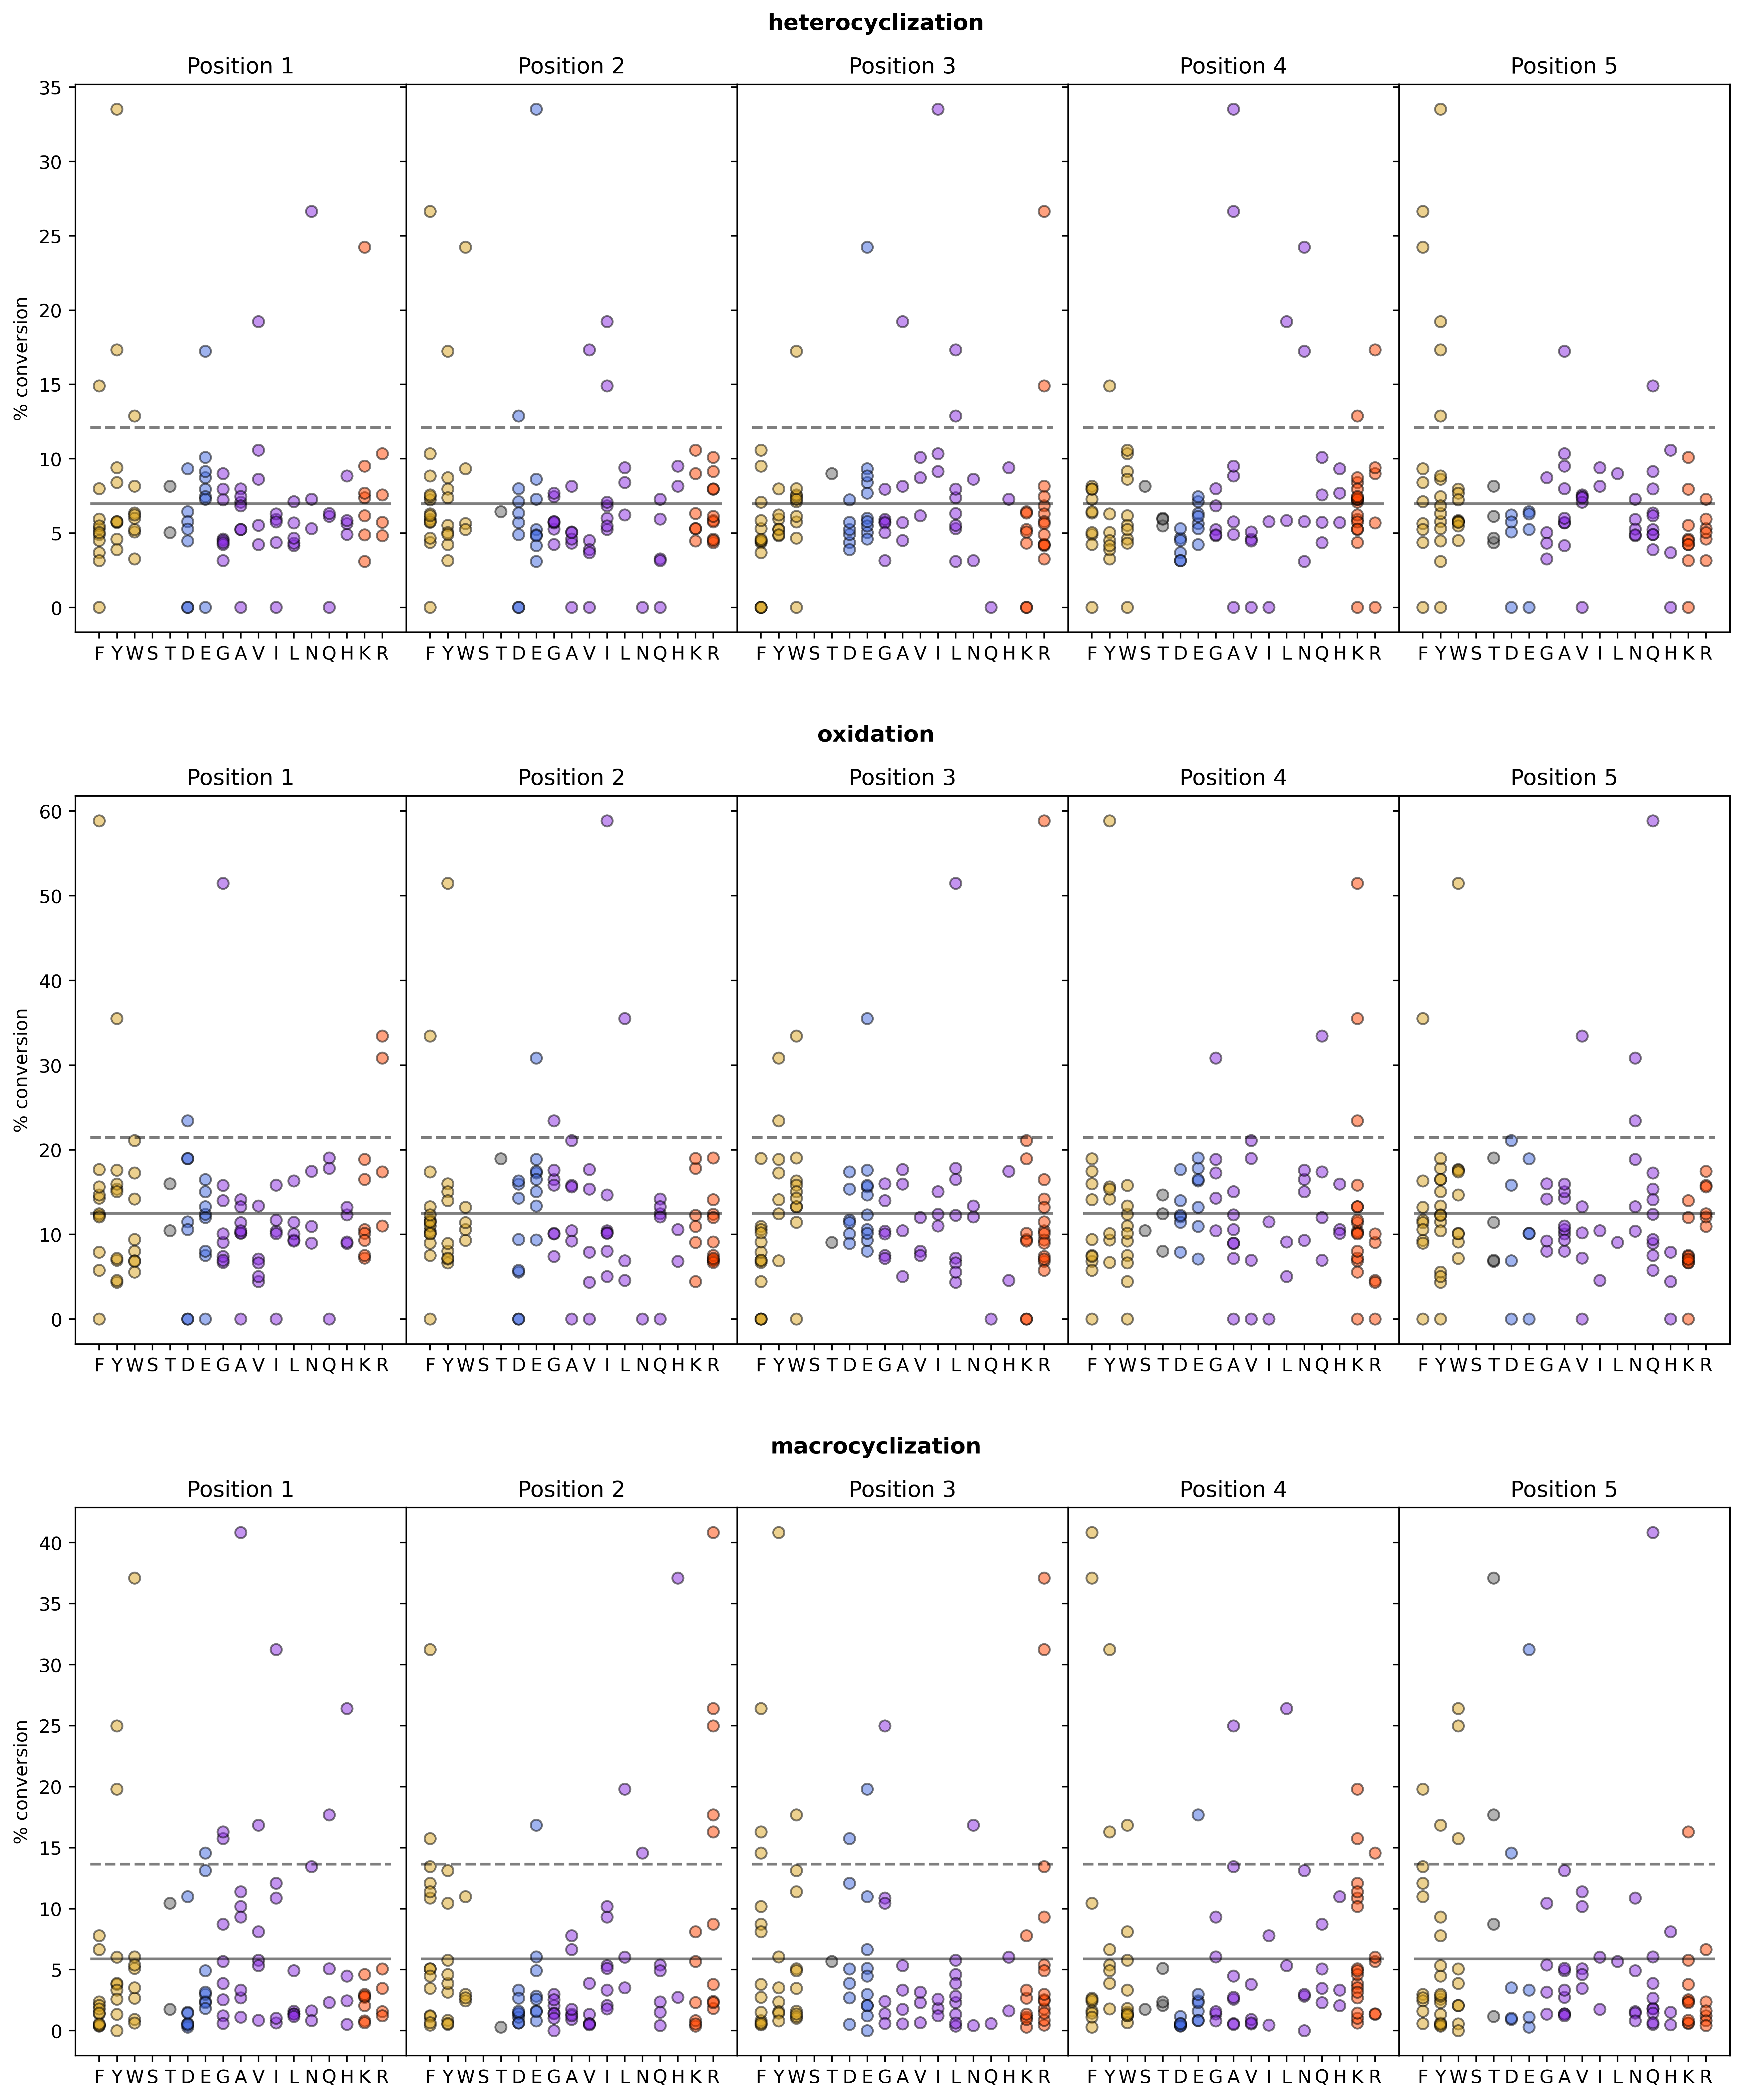

In [68]:
rows = ['aa1', 'aa2', 'aa3', 'aa4', 'aa5']
cols = ['heterocyclization', 'oxidation', 'macrocyclization']
#ticks = sorted(data['aa4'].unique().tolist())
#sorted same as categories
ticks = ['F', 'Y', 'W', 'S', 'T', 'D', 'E', 'G',
         'A', 'V', 'I', 'L', 'N', 'Q', 'H', 'K', 'R']

fig = plt.figure(figsize=(16, 16), dpi=400)
#fig.suptitle('Residue-wise conversion')
fig.subplots_adjust(wspace=0)

# 2x1 subfigs
subfigs = fig.subfigures(nrows=3, ncols=1)
for response, subfig in zip(cols , subfigs):
    subfig.suptitle(f'{response}', weight='bold')

    # create 1x5 subplots per subfig
    axs = subfig.subplots(nrows=1, ncols=5, sharey=True)
    for (nr, resi), ax in zip(enumerate(rows), axs):
        d = data.sort_values(resi, ascending=True)
        x = d[resi]
        C = [colordict[inv_cat_dict[i]] for i in x]
        x = [ticks.index(i) + 0.5 for i in x]
        y = d[response]
        ax.scatter(x, y,  alpha=0.5, c=C, edgecolors='k');
        ax.set_title(f'Position {nr+1}');
        if nr == 0:
            ax.set_ylabel('% conversion')
        ax.hlines(y.mean(), 0, len(ticks), colors='k', alpha=0.5)
        ax.hlines(y.std() + y.mean(), 0, len(ticks), colors='k', linestyles='dashed', alpha=0.5)

    plt.setp(axs, xticks= [i+0.5 for i in range(len(ticks))], xticklabels=ticks);

plt.savefig('residue-wise_fx')

In [69]:
data['c1'] = pd.Series([inv_cat_dict[i] for i in list(data['aa1'])]).astype('category');
data['c2'] = pd.Series([inv_cat_dict[i] for i in list(data['aa2'])]).astype('category');
data['c3'] = pd.Series([inv_cat_dict[i] for i in list(data['aa3'])]).astype('category');
data['c4'] = pd.Series([inv_cat_dict[i] for i in list(data['aa4'])]).astype('category');
data['c5'] = pd.Series([inv_cat_dict[i] for i in list(data['aa5'])]).astype('category');

In [70]:
def rand_jitter(arr):
    stdev = 0.015 * (max(arr) - min(arr))
    return arr + np.random.randn(len(arr)) * stdev

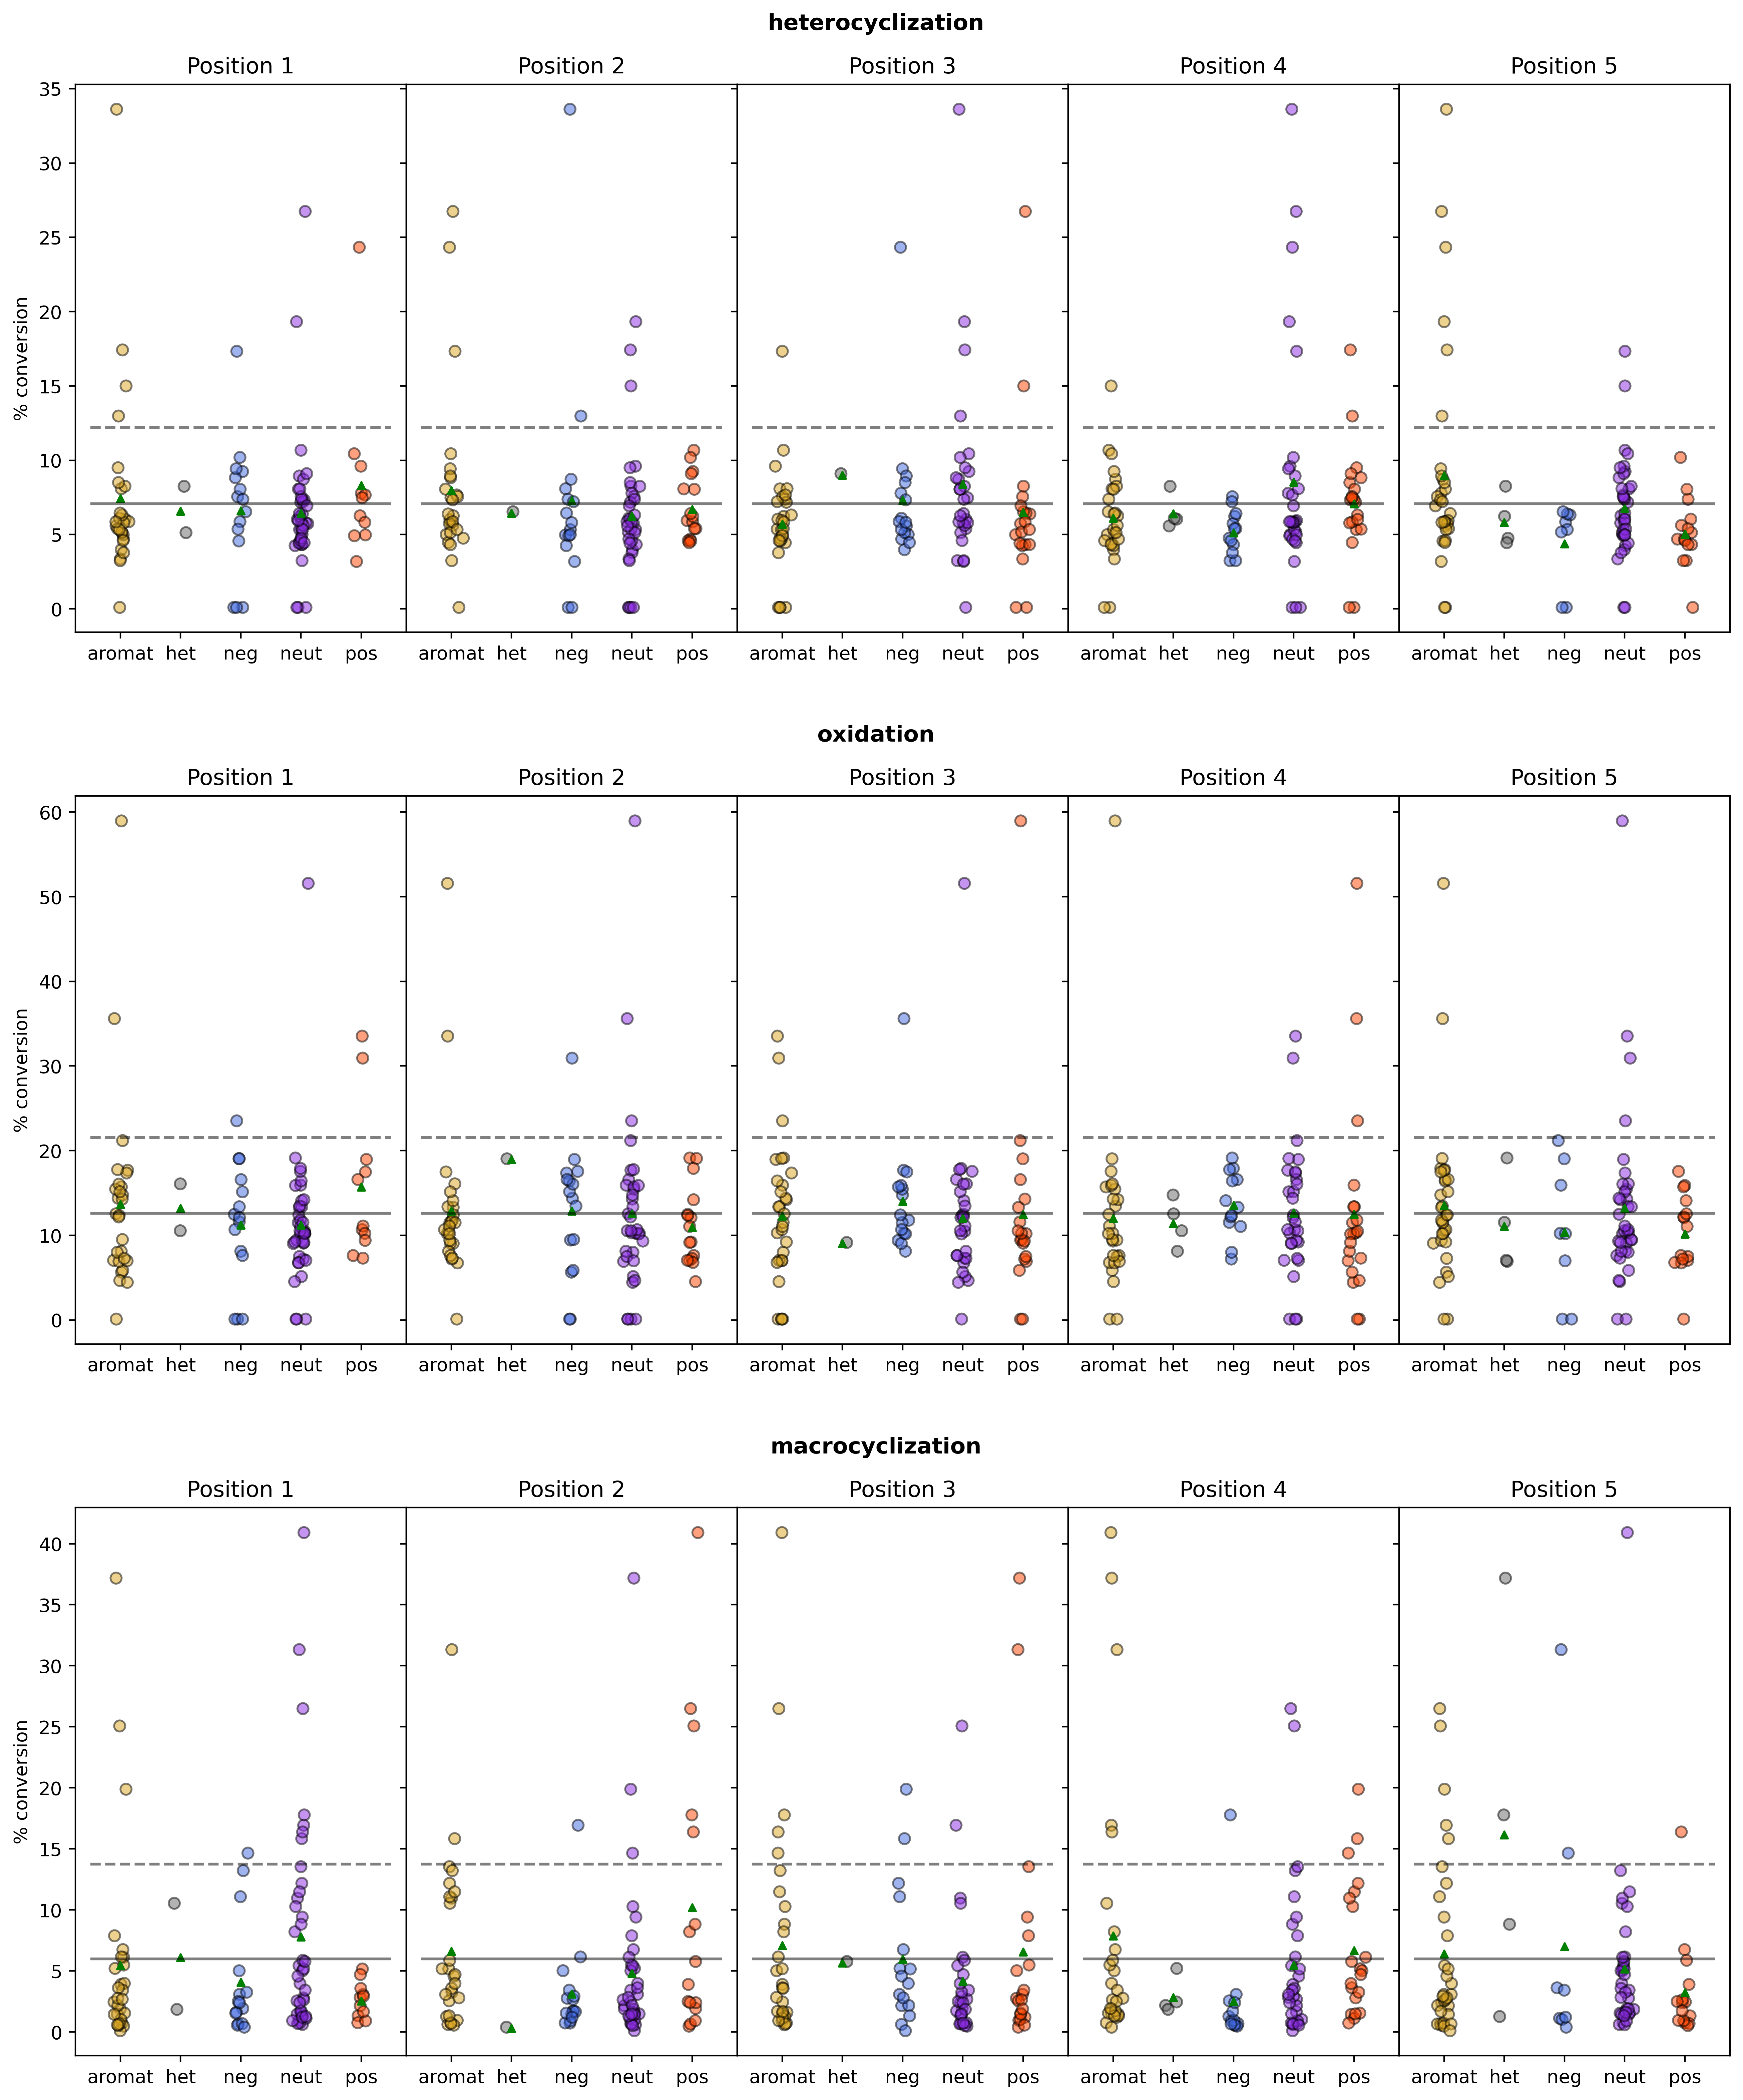

In [71]:
rows = ['c1', 'c2', 'c3', 'c4', 'c5']
cols = ['heterocyclization', 'oxidation', 'macrocyclization']
ticks = sorted(data['c4'].unique().tolist())

fig = plt.figure(figsize=(16, 16), dpi=400)
#fig.suptitle('Residue-wise conversion', weight='bold')
fig.subplots_adjust(wspace=0)

# 2x1 subfigs
subfigs = fig.subfigures(nrows=3, ncols=1)
for response, subfig in zip(cols, subfigs):
    subfig.suptitle(f'{response}', weight='bold')

    # 1x4 subplots per subfig
    axs = subfig.subplots(nrows=1, ncols=5, sharey=True)
    for (nr, resi), ax in zip(enumerate(rows), axs):
        d = data.sort_values(resi, ascending=True)
        x = d[resi]
        C = [colordict[i] for i in x]
        xx = [ticks.index(i) + 0.5 for i in x]
        xx = rand_jitter(xx)
        y = d[response]+0.1
        ax.scatter(xx, y,  alpha=0.5, c=C, edgecolors='k');
        m_y = [d.loc[d[resi] == i, response].mean() for i in ticks]
        m_x = np.array(range(len(ticks)))+0.5
        ax.scatter(m_x, m_y, s=15, c='g', marker='^')
        ax.set_title(f'Position {nr+1}');
        if nr == 0:
            ax.set_ylabel('% conversion')
        ax.hlines(y.mean(), 0, len(ticks), colors='k', alpha=0.5)
        ax.hlines(y.std() + y.mean(), 0, len(ticks), colors='k', 
                  linestyles='dashed', alpha=0.5)
        #ax.set_yscale('log')

    plt.setp(axs, xticks=[i+0.5 for i in range(len(ticks))], xticklabels=ticks);
plt.savefig('individual_effects')

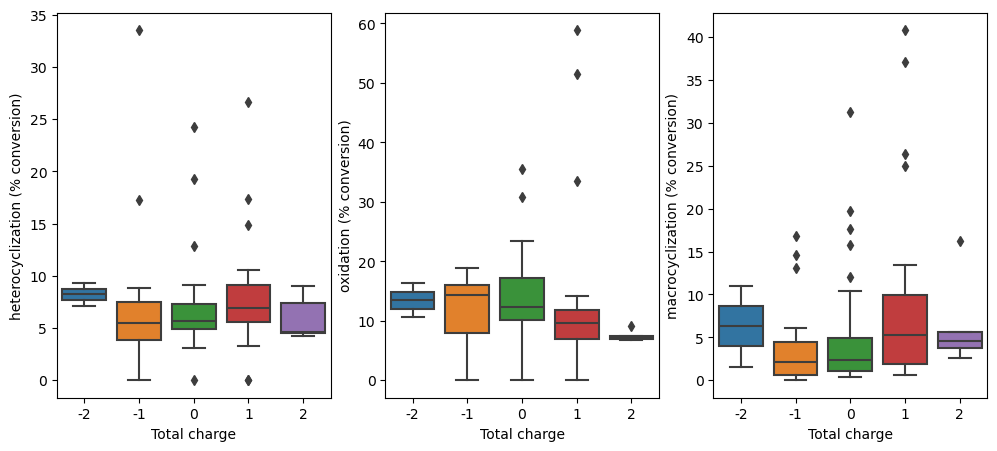

In [72]:
data.loc[:,'tot_charge'] = data.loc[:,['c1', 'c2', 'c3', 'c4', 'c5']].apply(
    lambda x: sum([charge[i] for i in x]) , axis=1)

fig, ax = plt.subplots(nrows=1,ncols=3, figsize=(12,5))
sns.boxplot(data=data, x='tot_charge', y='heterocyclization', ax=ax[0]);
sns.boxplot(data=data, x='tot_charge', y='oxidation', ax=ax[1]);
sns.boxplot(data=data, x='tot_charge', y='macrocyclization', ax=ax[2]);

ax[0].set_ylabel('heterocyclization (% conversion)')
ax[1].set_ylabel('oxidation (% conversion)')
ax[2].set_ylabel('macrocyclization (% conversion)')
for i in range(3):
    ax[i].set_xlabel('Total charge')

plt.savefig('charge_vs_conversion')

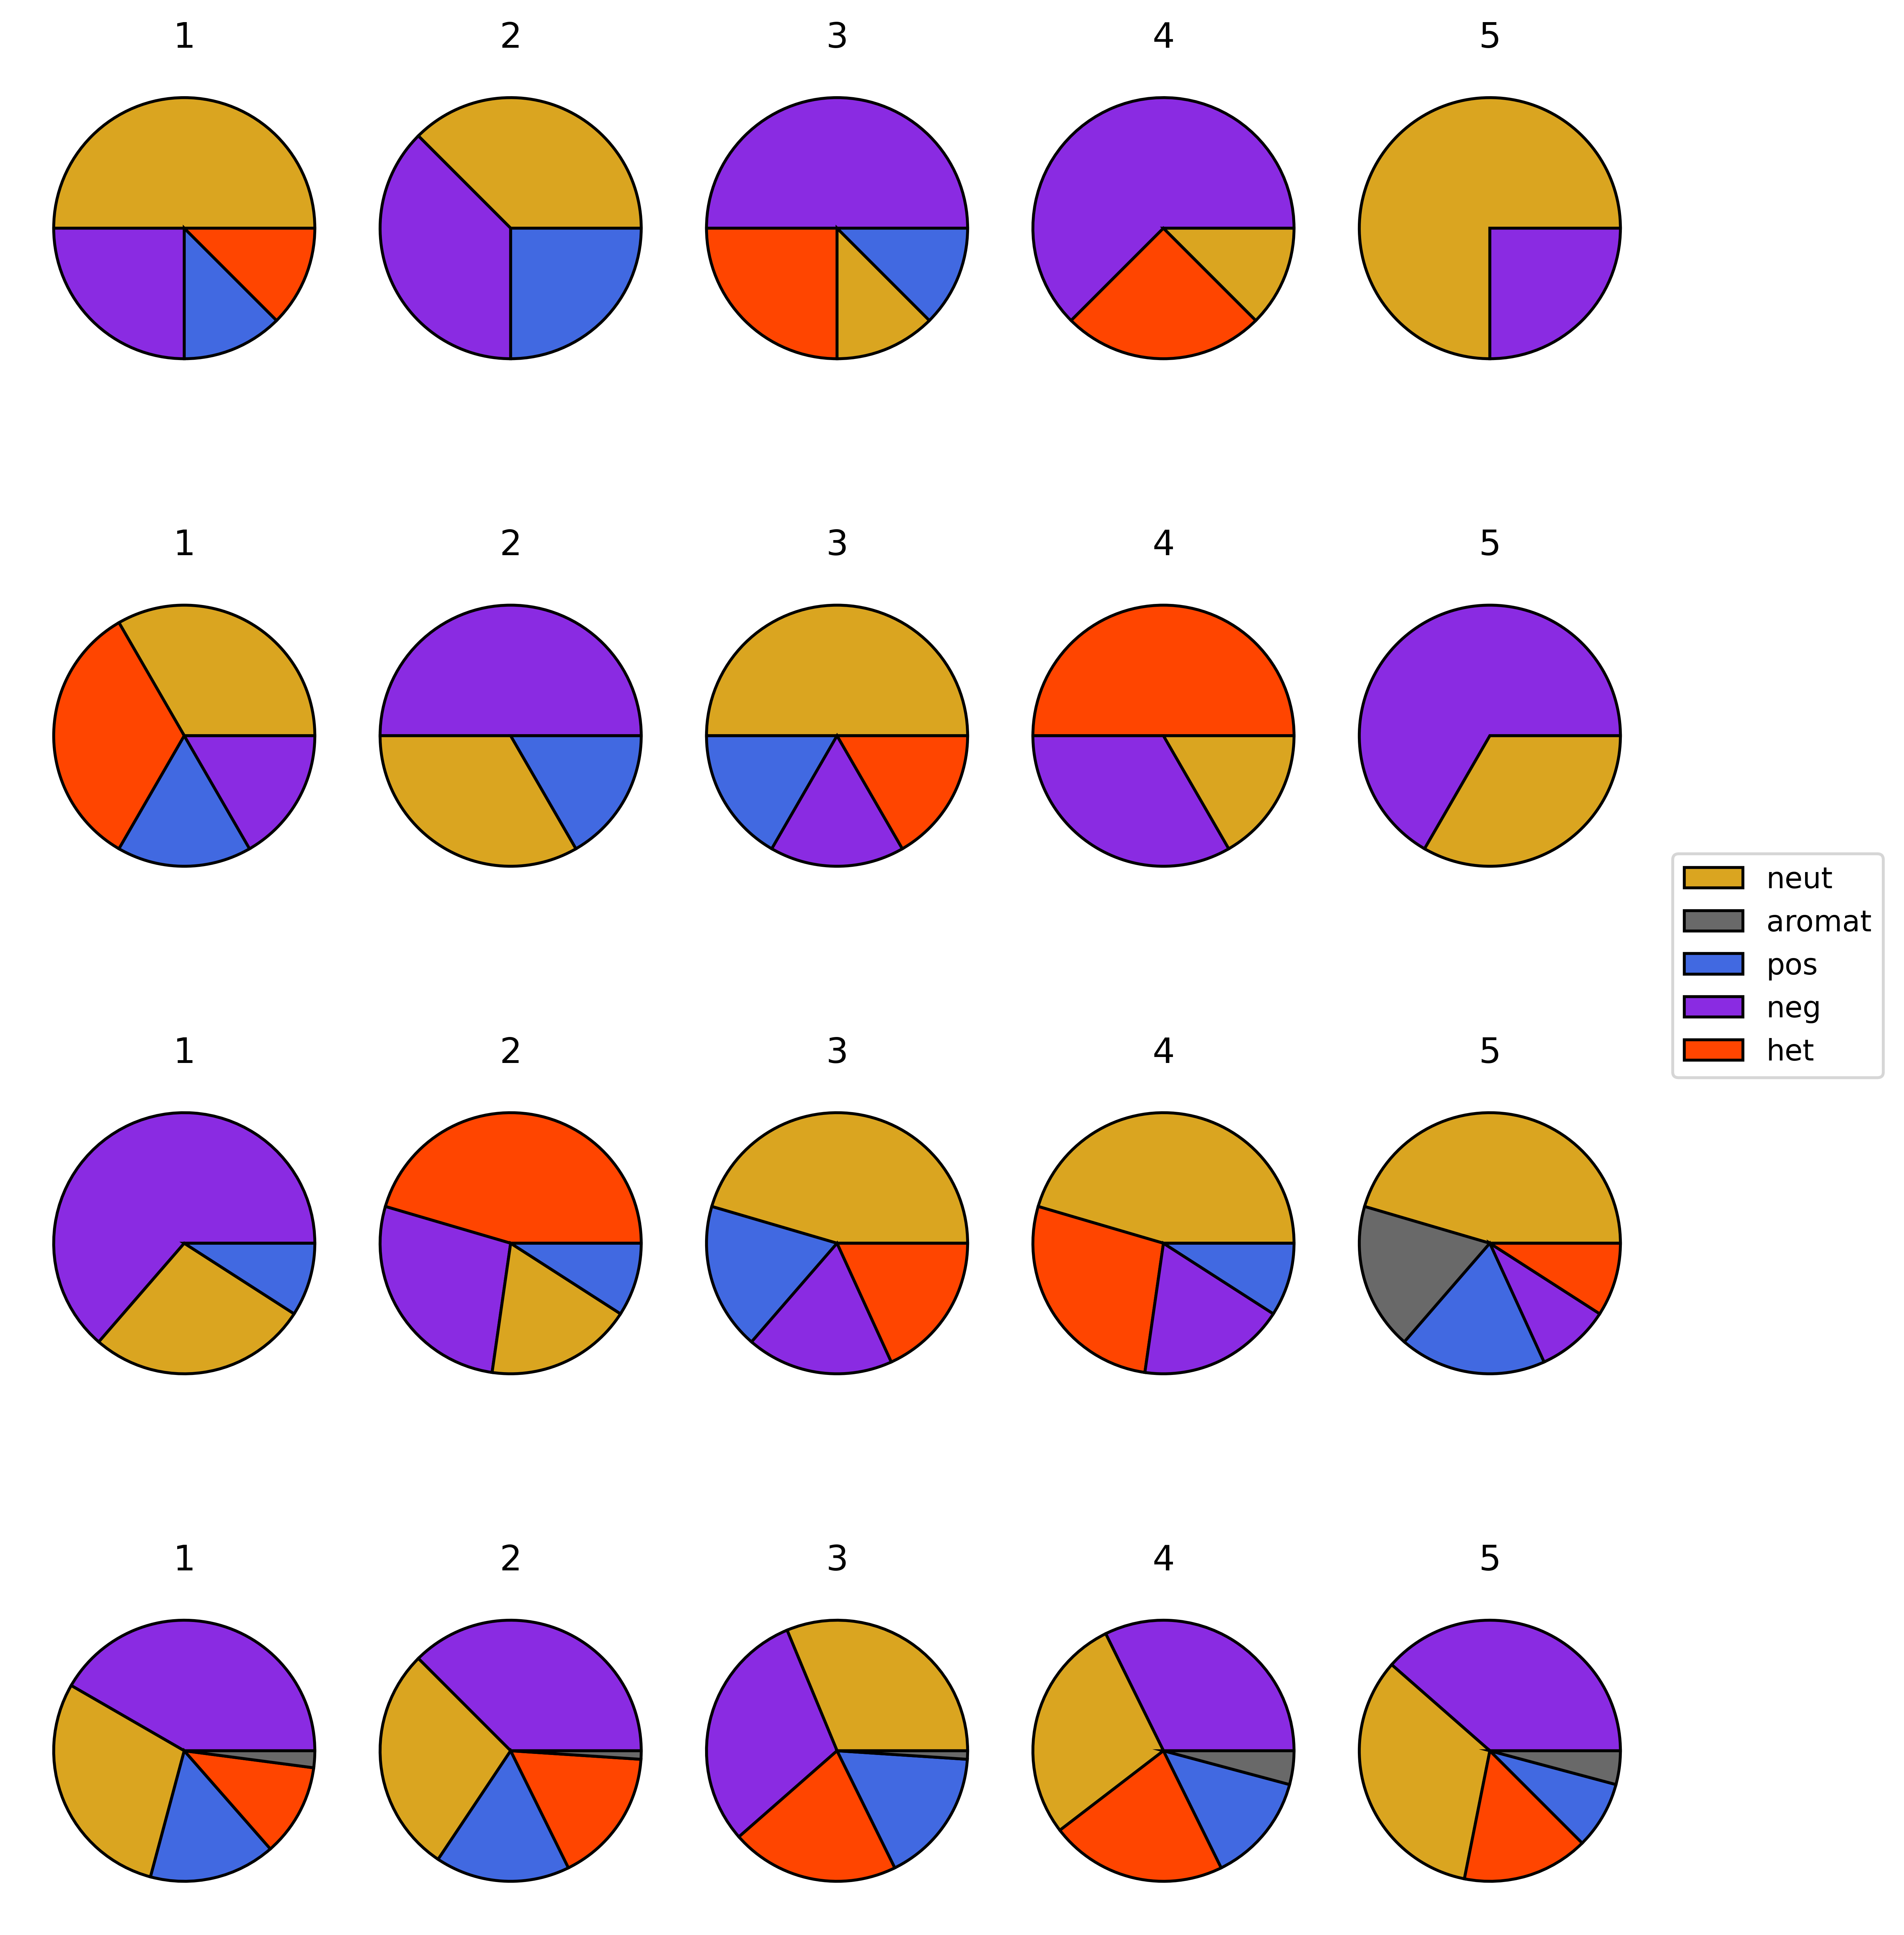

In [81]:
proper = ['heterocyclization', 'oxidation', 'macrocyclization']
position = ['c1','c2', 'c3', 'c4', 'c5']

fig, ax = plt.subplots(nrows=4,ncols=5, figsize=(10,12), dpi=600)
fig.subplots_adjust(wspace=0)

for (row, rxn), (col, pos) in list(product(enumerate(proper), enumerate(position))):
    mask = data.sort_values(rxn, 
                             ascending=False)[rxn] >= (data[rxn].mean() 
                                                       + data[rxn].std())
    counts = data.sort_values(rxn, ascending=False)[pos].loc[mask].value_counts()
    labels = counts.index
    x = [i for i, j in zip(counts, labels) if i!=0]
    y = [j for i, j in zip(counts, labels) if i!=0]
    color = [colordict[i] for i in y]
    patches, text = ax[row, col].pie(x, labels=None, colors=color, 
                     wedgeprops={'edgecolor':'k', 'linewidth': 1});
    ax[row, col].set_title(col+1)
    
for i, pos in enumerate(position):
    counts = data[pos].value_counts()
    labels = counts.index
    x = [i for i, j in zip(counts, labels) if i!=0]
    y = [j for i, j in zip(counts, labels) if i!=0]
    color = [colordict[i] for i in y]
    ax[3, i].pie(x, labels=None, colors=color, 
                     wedgeprops={'edgecolor':'k', 'linewidth': 1});
    ax[3, i].set_title(i+1)
    
ax[2,4].legend(patches, labels, loc='center right', bbox_to_anchor=(1.75 , 1.35))
plt.savefig('position-wise-topconverters-pie_het_ox_mac_overall.pdf', format='pdf')

In [71]:
data[proper].describe()

,heterocyclization,oxidation,macrocyclization
count,96.000000,96.000000,96.000000
mean,6.980898,12.495263,5.886042
std,5.128875,8.961279,7.773610
min,0.000000,0.000000,0.000000
25%,4.641375,7.509939,1.353149
50%,5.808218,10.966487,2.783404
75%,7.960949,15.654581,6.197900
max,33.517465,58.845193,40.813287
